In [32]:
# import libraries
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# load directories
from hbn.constants import Defaults
from hbn.visualization import visualize as vis
from hbn.features.build_features import _index_dataframe_by_columns_values

import plotly.io as pio
pio.renderers.default = 'notebook'

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
### DEFINE VARIABLES ###

model_parent = 'reading_feb_2024B'

models = glob.glob(os.path.join(Defaults.MODEL_DIR, model_parent, '*'))


### Load Results

In [48]:
# load model results

data = pd.DataFrame()
for model in models:
    # read model summary into pd dataframe
    df = pd.read_csv(os.path.join(model, 'model-summary.csv'), engine='python')

    # append dataframe
    data = pd.concat([data, df])


### Firstlevel models (data and null)

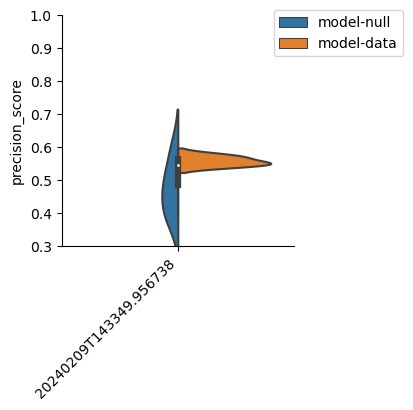

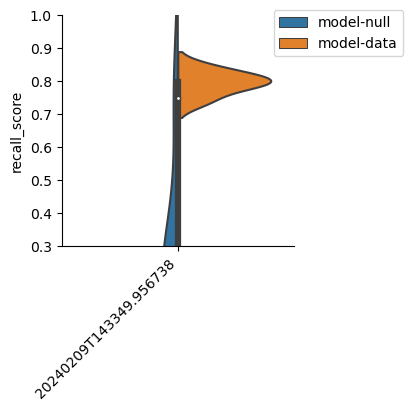

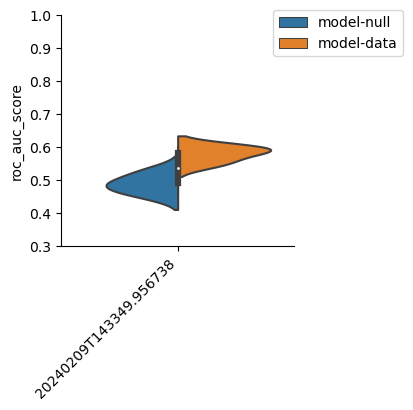

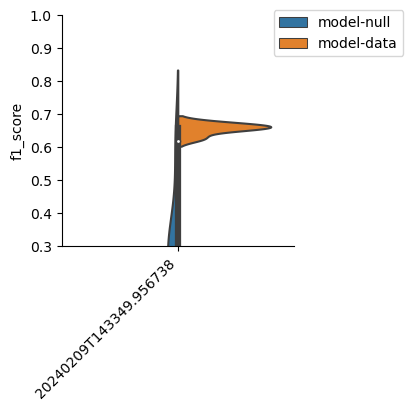

In [36]:
columns = []
values_list = []

df_filter = data
if len(columns)>0:      
    df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

metrics = ['precision_score', 'recall_score', 'roc_auc_score', 'f1_score']

for metric in metrics:
    vis.violinplot(x='model', y=metric, hue='data', data=df_filter, title='')

### First and secondlevel models

In [47]:
columns = ['data']
values_list = [['model-data']]

df_filter = data
if len(columns)>0:      
    df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

vis.violinplot(x='model', y='roc_auc_score', hue='model_type', data=df_filter, title='')